## Our Framework Evaluation with WiFi Dataset by Jagannath et al.

Dataset: [link](https://ieee-dataport.org/documents/real-world-commercial-wifi-and-bluetooth-dataset-rf-fingerprinting)

In [2]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
import json
import matplotlib.pyplot as plt
import utils
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI

2024-10-22 04:40:27.628963: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-22 04:40:27.629026: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-22 04:40:27.629777: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-22 04:40:27.633992: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-22 04:40:28.271670: W tensorflow/compiler/tf2

In [3]:
DIR = '/home/smazokha2016/Desktop/jagannath_dataset_raw/Day1WIFIwb/'

/home/shared/socom/WiFi/RASP_PI4_80211g_OFDM_OTA_TX30_1000000077277365_IQ.dat
/home/smazokha2016/Desktop/jagannath_dataset_raw/Day1WIFIwb/RASP_PI4_80211g_OFDM_OTA_TX30_1000000077277365_IQ.dat
(40000000,)


/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/smazokha2016/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


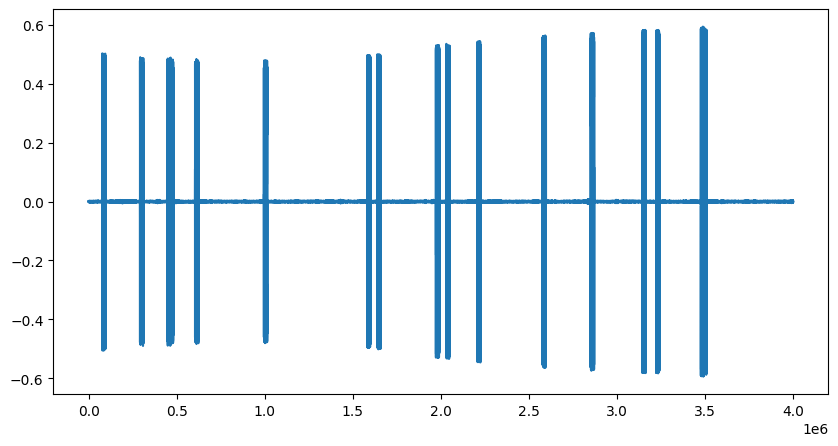

In [4]:
def read_json_file(file_path):
    with open(file_path) as json_file:
        # Read and extract required metadata fields
        data = json.load(json_file)
        samp_rate = data["global"]["core:sample_rate"]
        rxgain = data["annotations"]["receiver"]["core:gain"]
        data_file = data["annotations"]["receiver"]["core:filename"]
        frequency = data["captures"]["core:center_frequency"]
        sample_count = data["annotations"]["core:sample_count"]
        addr = data["annotations"]["receiver"]["core:radio_ip_addr"]
        emitter_id = data["annotations"]["transmitter"]["core:radio_id"]
        wireless_protocol = data["annotations"]["core:protocol"]
        sample_start = data["captures"]["core:sample_start"]

        print(data_file)

def read_data_file(file_path):
    print(file_path)

    with open(file_path) as data_file:
        data = np.fromfile(data_file, dtype=np.complex64) 
    return data

for file_name in os.listdir(DIR):
    if file_name.endswith('_IQ.meta.json'):
        meta_file_path = os.path.join(DIR, file_name)
        data_file_path = os.path.join(DIR, file_name.replace('_IQ.meta.json', '_IQ.dat'))
        read_json_file(meta_file_path)
        iq = read_data_file(data_file_path)

        print(iq.shape)

        plt.figure(figsize=(10, 5), dpi=100)
        plt.plot(iq[0:4000000])
        break

In [4]:
for file in os.listdir(DIR):
    # Find .json files
    if file.endswith("_IQ.meta.json"):

        print(file)
        
        with open(file) as json_file:
            # Read and extract required metadata fields
            data = json.load(json_file)
            samp_rate = data["global"]["core:sample_rate"]
            rxgain = data["annotations"]["receiver"]["core:gain"]
            data_file = data["annotations"]["receiver"]["core:filename"]
            frequency = data["captures"]["core:center_frequency"]
            sample_count = data["annotations"]["core:sample_count"]
            addr = data["annotations"]["receiver"]["core:radio_ip_addr"]
            emitter_id = data["annotations"]["transmitter"]["core:radio_id"]
            wireless_protocol = data["annotations"]["core:protocol"]
            sample_start = data["captures"]["core:sample_start"]
            # fp = open(data_file, "rb")
            # fp.seek(sample_start * sample_count, 0)
            # The IQ samples from the binary file
            # data = np.fromfile(fp, dtype=np.complex64, count=40000000) 

RASP_PI4_80211g_OFDM_OTA_TX30_1000000077277365_IQ.meta.json


FileNotFoundError: [Errno 2] No such file or directory: 'RASP_PI4_80211g_OFDM_OTA_TX30_1000000077277365_IQ.meta.json'